# Load Data

In [3]:
#分子描述符，电子的供体和受体特性
import pickle
import pandas as pd
from tqdm import tqdm
from sklearn.ensemble import RandomForestRegressor
from rdkit.Chem import rdMolDescriptors
from rdkit import RDLogger,Chem
import numpy as np
RDLogger.DisableLog('rdApp.*')

In [2]:
dataset_dir = '../data'   # Change this to your dataset directory

train_df_round1 = pd.read_csv(f'{dataset_dir}/round1_train_data.csv')
train_df_round2 = pd.read_csv(f'{dataset_dir}/round2_train_data.csv')

train_df_round1['rxntype'] = 1

train_df = pd.concat([train_df_round1, train_df_round2])

print(f'Training set size: {len(train_df)}')

grouped = train_df.groupby('rxntype')

# 将拆分后的 DataFrame 存储在一个字典中，键为 rxntype 值，值为对应的 DataFrame
# train_dflist = [group for group in grouped]
train_df_dict = {rxntype: group for rxntype, group in grouped}

Training set size: 96852


In [3]:

train_df.iloc[31563]

rxnid                     train31564
Reactant1                   CC(=O)Cl
Reactant2          CCOC(=O)c1ccccc1N
Product      CCOC(=O)c1ccccc1NC(C)=O
Additive                   CCN(CC)CC
Solvent                      C1CCOC1
Yield                          1.595
rxntype                            8
Name: 8025, dtype: object

In [4]:
df =train_df_dict[8]
for i in range(len(df)):
    if df.iloc[i].Yield>1:
        print(i)

2867


In [5]:
train_df.iloc[73300]

rxnid                                               train73301
Reactant1                                       Brc1ccc(Br)cc1
Reactant2      C#Cc1c2ccccc2c(C#Cc2sccc2CCCCCCCCCCCC)c2ccccc12
Product      CCCCCCCCCCCCc1ccsc1C#Cc1c2ccccc2c(C#Cc2ccc(Br)...
Additive     CC(C)NC(C)C.[Cl-].[Cl-].[Pd+2].c1ccc(P(c2ccccc...
Solvent                                                C1CCOC1
Yield                                                     0.66
rxntype                                                      6
Name: 49762, dtype: object

## Reactant1

都是单分子

In [6]:
from rdkit import Chem

def canonize_line(smis):
    smis=list(set(smis.split('.')))    
    smis=[Chem.MolToSmiles(Chem.MolFromSmiles(smi), isomericSmiles=True, canonical=True) for smi in smis]
    return '.'.join(list(set(smis)))
    
columns=['Reactant1','Reactant2','Product','Additive','Solvent']
i_rxn=1
icol=0
print(columns[icol])
special_set={'Cl',}
for i_rxn in range(1,9):
    printcount=0
    components = train_df_dict[i_rxn][columns[icol]].to_list()
    num_multicomponents={}
    for i in range(len(components)):
        smis=canonize_line(components[i])
        if smis.count('.')>0:
            tmpcounts=smis.count('.')+1
            if tmpcounts not in num_multicomponents:
                num_multicomponents[tmpcounts]=1
            else:
                num_multicomponents[tmpcounts]+=1
            if tmpcounts>1 and printcount<10:
                printcount+=1
                # smislist=smis.split('.')                 
                print(f"Line {i}: {smis}",train_df_dict[i_rxn].iloc[i]) 
                # line=train_df_dict[i_rxn].iloc[i].tolist()
        else:
            pass
    print(f"reaction:{i_rxn}",num_multicomponents)

Reactant1


reaction:1 {}
Line 266: Cl.Brc1ccncc1 rxnid                                               train24970
Reactant1                                        Brc1ccncc1.Cl
Reactant2                    CC1(C)OB(c2cc(Cl)nc(Cl)c2)OC1(C)C
Product                              Clc1cc(-c2ccncc2)cc(Cl)n1
Additive     CC(=O)[O-].CC(=O)[O-].[Pd+2].O=C([O-])[O-].[K+...
Solvent                                             C1COCCO1.O
Yield                                                     0.41
rxntype                                                      2
Name: 1431, dtype: object
Line 330: O=S(=O)(O)F.O=[N+]([O-])c1ccccc1 rxnid                                    train25270
Reactant1          O=S(=O)(O)F.O=[N+]([O-])c1ccccc1
Reactant2                             OB(O)c1ccccc1
Product             O=[N+]([O-])c1cccc(-c2ccccc2)c1
Additive     CC(=O)[O-].CC(=O)[O-].[Pd+2].CCN(CC)CC
Solvent                                       CCO.O
Yield                                          0.94
rxntype                  

In [7]:
for i_rxn in range(1,9):
    printcount=0
    print(f"Rxn_{i}_{len(train_df_dict[i_rxn])}")

Rxn_25939_23538
Rxn_25939_14455
Rxn_25939_5423
Rxn_25939_3292
Rxn_25939_6919
Rxn_25939_10465
Rxn_25939_6820
Rxn_25939_25940


## Reactant2

In [8]:
from rdkit import Chem

def canonize_line(smis):
    smis=list(set(smis.split('.')))    
    smis=[Chem.MolToSmiles(Chem.MolFromSmiles(smi), isomericSmiles=True, canonical=True) for smi in smis]
    return '.'.join(list(set(smis)))
    
columns=['Reactant1','Reactant2','Product','Additive','Solvent']
i_rxn=1
icol=1
print(columns[icol])
for i_rxn in range(1,9):
    components = train_df_dict[i_rxn][columns[icol]].to_list()
    num_multicomponents={}
    for i in range(len(components)):
        smis=canonize_line(components[i])
        if smis.count('.')>0:
            tmpcounts=smis.count('.')+1
            if tmpcounts not in num_multicomponents:
                num_multicomponents[tmpcounts]=1
            else:
                num_multicomponents[tmpcounts]+=1
            if tmpcounts>1:
                smislist=smis.split('.')                 
                # print(f"Line {i}: {smis}")                
                # line=train_df_dict[i_rxn].iloc[i].tolist()
        else:
            pass
    print(f"reaction:{i_rxn}",num_multicomponents)

Reactant2
reaction:1 {}
reaction:2 {2: 750}
reaction:3 {}
reaction:4 {2: 4}
reaction:5 {}
reaction:6 {}
reaction:7 {}
reaction:8 {}


## Product

### EDA

In [9]:
from rdkit import Chem

def canonize_line(smis):
    smis=list(set(smis.split('.')))    
    smis=[Chem.MolToSmiles(Chem.MolFromSmiles(smi), isomericSmiles=True, canonical=True) for smi in smis]
    return '.'.join(list(set(smis)))
    
columns=['Reactant1','Reactant2','Product','Additive','Solvent']
i_rxn=1
icol=2
print(columns[icol])
# for i_rxn in range(1,9):
for i_rxn in range(1,2):
    components = train_df_dict[i_rxn][columns[icol]].to_list()
    num_multicomponents={}
    for i in range(len(components)):
        # print(components[i])
        smis=canonize_line(components[i])
        if smis.count('.')>0:
            tmpcounts=smis.count('.')+1
            if tmpcounts not in num_multicomponents:
                num_multicomponents[tmpcounts]=1
            else:
                num_multicomponents[tmpcounts]+=1
            if tmpcounts>1:
                smislist=smis.split('.')
                if 'Cl' in smislist or 'O' in smislist or 'Br' in smislist or '[Br-]' in smislist or '[Cl-]' in smislist or '[NH4+]' in smislist:
                    pass             
                else:
                    print(f"Line {i}: {smis}")
        else:
            # print(additives[i])
            pass
    print(f"reaction:{i_rxn}",num_multicomponents)

Product
Line 1322: CC(=O)Nc1ccc(Cl)nc1N1CCC(n2c(=N)n(Cc3ccccc3Cl)c3ccc(F)cc32)CC1.O=C(O)C(F)(F)F
Line 7615: O=C(O)C(F)(F)F.COc1cccc(N(C)c2ccc3sc(-c4ccnc(N)n4)c(C)c3c2)c1
Line 7659: CC(C)(C)OC(=O)NC1CCN(c2cc(C3C4CC5CC(C4)CC3C5)nc(N)n2)C1.O=CO
Line 7886: Brc1ccc(N2CCN3CCC2CC3)nn1.O=C(O)/C=C/C(=O)O
Line 8162: CC(C)N1CCN(c2ccc3c(C(=O)N4CCN5CCC4CC5)nsc3c2)C1=O.O=CO
Line 8693: O=CO.COc1cc2nncc(-n3ccc4cc(N5CCOCC5)ccc43)c2cc1OC
Line 11216: O=CO.N#Cc1cccc(N2CC[C@H](S(=O)(=O)c3ccc(N4CCN5CCC[C@H]5C4)cc3Cl)C2)n1
Line 11866: O=C(O)C(F)(F)F.CC(C)(C)C(=O)NCCC1CCN(c2ncnc3cc(C(=O)O)sc23)CC1
Line 17569: O=S(=O)(O)O.CN(N)c1cccc(Br)n1
Line 18375: O=C(O)C(F)(F)F.Cn1c2ccncc2c2ccc(N3CCC(OCCF)CC3)nc21
reaction:1 {2: 114}


In [10]:
from rdkit import Chem
import warnings
warnings.filterwarnings("ignore", message='not removing hydrogen atom with dummy atom neighbors')

def canonize_line(smis):
    smis=list(set(smis.split('.')))    
    smis=[Chem.MolToSmiles(Chem.MolFromSmiles(smi), isomericSmiles=True, canonical=True) for smi in smis]
    return smis
    
columns=['Reactant1','Reactant2','Product','Additive','Solvent']

i_rxn=1
icol=2
print(columns[icol])
colset=set()
# for i_rxn in range(1,9):
for i_rxn in range(1,2):
    components = train_df_dict[i_rxn][columns[icol]].to_list()
    num_multicomponents={}
    for i in range(len(components)):
    # for i in range(16):            
        smis=canonize_line(components[i])
        colset.update(smis)
print(f"Col:{columns[icol]}",len(colset))

Product
Col:Product 21292


In [11]:
for smi in colset:
    if len(smi)<8: print(smi)

[NH4+]
[Cl-]
O
[Br-]
Cl
O=CO
Br


### 正式处理

In [12]:
byprod=["O=C(O)C(F)(F)F","O=CO","O=C(O)/C=C/C(=O)O","O=S(=O)(O)O",'Cl','O','Br','[Br-]','[Cl-]','[NH4+]']
byprod_dict={byprod[i]:i for i in range(len(byprod))}

In [13]:
def top_k_longest_indices(string_list, k):
    # 使用 sorted 按照字符串的长度从大到小对索引进行排序
    sorted_indices = sorted(range(len(string_list)), key=lambda i: len(string_list[i]), reverse=True)
    return sorted_indices[:k]

stringlist=["a","aaa","aa"]
top_k_longest_indices(stringlist,2)

[1, 2]

In [14]:
components[:16]

['Brc1ccccc1N1c2ccccc2Oc2ccccc21',
 'Brc1ccccc1N1c2ccccc2Oc2ccccc21',
 'Brc1ccccc1N1c2ccccc2Oc2ccccc21',
 'Fc1cnc(Cl)nc1N1CCOCC1',
 'Fc1cnc(Cl)nc1N1CCOCC1',
 'FC(F)(F)c1ccc(N2CCN(c3ccc(C(F)(F)F)cn3)CC2)nc1',
 'CN(CCO)c1sc(-c2ccc(Cl)cc2)nc1C(F)(F)F',
 'Fc1ccc(-n2ccc3ccccc32)cc1',
 'Fc1ccc(-n2ccc3ccccc32)cc1',
 'Fc1ccc(-n2ccc3ccccc32)cc1',
 'Fc1ccc(-n2ccc3cc(F)ccc32)cc1',
 'Fc1ccc(-n2ccc3cc(F)ccc32)cc1',
 'Fc1ccc(-n2ccc3cc(F)ccc32)cc1',
 'CC(=O)N(c1cccnc1)c1ccccc1C(F)(F)F',
 'CCOC(=O)N1CCN(c2ncc(F)c(SC)n2)CC1',
 'COCCN(N)c1nc2cc(C(F)(F)F)ccc2o1.Cl']

## Additives

### EDA

In [15]:
pattern = [ #Morded
        "[C,c]",
]
pattern_mol=[Chem.MolFromSmarts(pat) for pat in pattern]

def search_pattern(smiles):
    mol=Chem.MolFromSmiles(smiles)
    match=False
    for patmol in pattern_mol:
        if len(mol.GetSubstructMatches(patmol))>0:
            match=True
    return match

In [16]:
from rdkit import Chem

def canonize_line(smis):
    smis=list(set(smis.split('.')))    
    smis=[Chem.MolToSmiles(Chem.MolFromSmiles(smi), isomericSmiles=True, canonical=True) for smi in smis]
    return '.'.join(list(set(smis)))

def canonize_line2(smis):
    # smis=smis.split('.')
    smisset=set(smis.split('.'))
    # for i in range(len(smis)):
    #     if smis[i] not in special_additives_dict:
    #         smisset.add(smis[i])
    smis=[Chem.MolToSmiles(Chem.MolFromSmiles(smi), isomericSmiles=True, canonical=True) for smi in smisset]
    return '.'.join(list(set(smis)))
    
columns=['Reactant1','Reactant2','Product','Additive','Solvent']
i_rxn=1
icol=3
print(columns[icol])

for i_rxn in range(1,9):
# for i_rxn in range(1,2):
    components = train_df_dict[i_rxn][columns[icol]].to_list()
    num_multicomponents={}
    for i in range(len(components)):
        # print(components[i])
        smis=canonize_line2(components[i])
        if smis.count('.')>0:
            tmpcounts=smis.count('.')+1
            if tmpcounts not in num_multicomponents:
                num_multicomponents[tmpcounts]=1
            else:
                num_multicomponents[tmpcounts]+=1            
            if tmpcounts>8:
                smislist=smis.split('.')
                # if 'Cl' in smislist or 'O' in smislist or 'Br' in smislist or '[Br-]' in smislist or '[Cl-]' in smislist or '[NH4+]' in smislist:
                #     pass             
                # else:
                # print(f"Line {i}: {smis}")
            tmp_count=0
            for smile in smis.split('.'):
                if search_pattern(smile): tmp_count+=1
            # if tmp_count==0: 
            #     print(smile)
        else:
            # print(additives[i])
            pass
        if "BOP" in smis:
            print(smis)
    print(f"reaction:{i_rxn}",num_multicomponents)

Additive
reaction:1 {7: 87, 5: 5445, 2: 7852, 4: 1118, 3: 1180, 6: 394, 8: 13, 9: 1}
reaction:2 {4: 7680, 5: 4365, 6: 1340, 7: 252, 3: 426, 2: 302, 8: 72, 9: 6, 10: 2}
reaction:3 {2: 425, 4: 2318, 5: 991, 3: 1043, 6: 470, 7: 171, 8: 5}
reaction:4 {2: 1524, 3: 336, 4: 228, 5: 65, 6: 7, 7: 3}
reaction:5 {8: 13, 3: 409, 5: 4735, 6: 426, 4: 456, 2: 749, 7: 60, 9: 2}
reaction:6 {5: 2949, 6: 6771, 7: 522, 4: 134, 8: 80, 9: 8, 3: 1}
reaction:7 {2: 2703, 5: 139, 3: 529, 4: 333, 7: 15, 6: 5}
BOP.CCN(C(C)C)C(C)C
reaction:8 {2: 6188, 3: 6297, 4: 2811, 6: 17, 5: 137, 7: 3}


In [17]:
from rdkit import Chem

def canonize_line(smis):
    smis=list(set(smis.split('.')))    
    smis=[Chem.MolToSmiles(Chem.MolFromSmiles(smi), isomericSmiles=True, canonical=True) for smi in smis]
    return '.'.join(list(set(smis)))

def canonize_line2(smis):
    smis=smis.split('.')
    smisset=set()
    for i in range(len(smis)):
        if smis[i] not in special_additives_dict:
            smisset.add(smis[i])
    smis=[Chem.MolToSmiles(Chem.MolFromSmiles(smi), isomericSmiles=True, canonical=True) for smi in smisset]
    return '.'.join(list(set(smis)))
    
columns=['Reactant1','Reactant2','Product','Additive','Solvent']
i_rxn=1
icol=3
print(columns[icol])
count=0
for i_rxn in range(1,9):
# for i_rxn in range(1,2):
    components = train_df_dict[i_rxn][columns[icol]].to_list()
    num_multicomponents={}
    for i in range(len(components)):
        # print(components[i])
        if "P" in components[i] or "p" in components[i] and "Pd" not in components[i]:
            count+=1
        # if "p" in components[i]:
        #     print(components[i])

Additive


In [18]:
count

46581

reaction:1 {4: 278, 2: 3826, 3: 2782, 5: 10}

In [19]:
from rdkit import Chem
import warnings
warnings.filterwarnings("ignore", message='not removing hydrogen atom with dummy atom neighbors')

def canonize_line(smis):
    smis=list(set(smis.split('.')))    
    smis=[Chem.MolToSmiles(Chem.MolFromSmiles(smi), isomericSmiles=True, canonical=True) for smi in smis]
    return smis
    
columns=['Reactant1','Reactant2','Product','Additive','Solvent']

i_rxn=1
icol=3
print(columns[icol])
addcolset=set()
for i_rxn in range(1,9):
# for i_rxn in range(1,2):
    components = train_df_dict[i_rxn][columns[icol]].to_list()
    num_multicomponents={}
    for i in range(len(components)):
    # for i in range(16):            
        smis=canonize_line(components[i])
        addcolset.update(smis)
print(f"Col:{columns[icol]}",len(addcolset))

Additive
Col:Additive 1771


In [25]:
count=0
for item in (addcolset-special_additives):
    if "P" in item and "Pd" not in item:
        print(item)

Cc1ccccc1OP(=O)(Oc1ccccc1C)Oc1ccccc1C
Pc1c(-c2ccccc2)ccc(C2CCCCC2)c1C1CCCCC1
CP(C)C
COc1ccc(-c2ccccc2-c2ccccc2P(C2CCCCC2)C2CCCCC2)cc1
COc1ccccc1-n1cccc1P(C1CCCCC1)C1CCCCC1
COc1c(C)c(C)c(-c2c(C(C)C)cc(C(C)C)cc2C(C)C)c(P(C(C)(C)C)C(C)(C)C)c1C
O=S(=O)([O-])c1ccccc1P(c1ccccc1S(=O)(=O)[O-])c1ccccc1S(=O)(=O)[O-]
O=P([O-])(O)O
CN(C)P(N(C)C)N(C)C
CC(C)(C)P(C(C)(C)C)C12CC3CC(CC(C3)C1)C2
CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2)c(C(C)C)c1-c1ccccc1
Cc1cc(C)c(C2=C(P(C3CCCCC3)C3CCCCC3)c3ccccc3C2)c(C)c1
Cc1ccccc1-c1ccccc1P(C(C)(C)C)C(C)(C)C
CN(C)c1ccc(P(C23CC4CC(CC(C4)C2)C3)C23CC4CC(CC(C4)C2)C3)cc1
CN(C)P(=O)(N(C)C)N(C)C
c1ccc(C2=C(P(C3CCCCC3)C3CCCCC3)C3c4ccccc4C2c2ccccc23)cc1
O=P([O-])([O-])[O-]
Cc1ccccc1-c1ccccc1P(C1CCCCC1)C1CCCCC1
O=P(c1ccccc1)(c1ccccc1)c1ccccc1C=NO
CC(C)(C)C[PH+](C(C)(C)C)C(C)(C)C
CN(C)c1ccccc1P(C12CC3CC(CC(C3)C1)C2)C12CC3CC(CC(C3)C1)C2
CCCP1(=O)OP(=O)(CCC)OP(=O)(CCC)O1
CCOP(OCC)OCC
O=C1[C@@H]2Cc3ccccc3N2[C@@H](c2ccccc2P(C2CCCCC2)C2CCCCC2)N1c1ccccc1
Cn1c(-c2ccccc2P(C2CCCCC

In [26]:
(colset - special_additives)

{'Cc1cc(-c2cnn3c2C(=O)N(c2ccc(C(F)(F)F)cc2)CC3CO)ccn1',
 'C[C@@H]1CN(c2nc(Cl)nc(N3C[C@@H]4OCCO[C@@H]4C3)n2)C[C@H](C)O1',
 'COC(=O)c1cc(C(=O)OC)cc(N2CCCC2)c1',
 'C=Cc1c(F)c(F)c(-n2c3ccccc3c3ccccc32)c(F)c1F',
 'CCn1cc(-n2ccc3ccc(Cl)c(F)c32)cn1',
 'CC1CCC(=O)N1c1ccncc1',
 'CN1CCN(C[C@@H]2CCC(=O)N2c2ccc([N+](=O)[O-])cc2)CC1',
 'Cc1nn(C)c(N(C)C)c1C=O',
 'O=C1O[C@]2(CC[C@H](CNc3ccc(-c4ccccc4F)nc3)CC2)CN1c1ccccn1',
 'OCCC1CCN(c2ncc(C(F)(F)F)c(N3CCN=C3c3ccnc4ccccc34)n2)CC1',
 'Cc1nc(-n2cccn2)nc(C)c1Br',
 'CCOC(=O)c1ccc(-n2nc(C(=O)OC)c3ccccc32)c([N+](=O)[O-])c1',
 'Cc1ccc2ccn(-c3ccc(F)cc3Cc3c(C)cnn3C)c2n1',
 'Clc1cccc2c1c1ccccc1n2-c1ccccc1-c1ccccc1',
 'c1cnc2c(N3CCOCC3)nc(-n3ccc(C4CCOCC4)n3)nc2c1',
 'COc1ccc(COc2ncnc3cc(N4CCOCC4)sc23)cc1',
 'CC1(C)NC(=O)N(c2ccc(F)c(C(F)F)c2)C1=O',
 'COc1cc2ncc(C#N)c(N(C)c3ccc(Cl)cc3Cl)c2cc1OC',
 'N#Cc1c(F)c(F)c(N2c3ccccc3Sc3ccccc32)c(F)c1F',
 'CCOc1cnc(Cl)nc1N1CCN(c2ccccc2)C(=O)C1',
 'CC1(N(Cc2ccc3c(c2)OCO3)c2nc(Cl)ncc2F)CC1',
 'CCCC1CCN1c1ncc(C(=O)NCc2cc(NS(=O

### Classification

催化剂至关重要，甚至可以基于催化剂来训练模型

In [23]:
catalyst_in_component=['[Pd]','[Pd-]','[Pd-2]','[Pd-3]','[Pd+]','[Pd+2]','Ni','Zn+','[Ru-2]','Mg']

In [ ]:
# catalyst=["[Pt+4]","[Fe+3]","[Ni+2]","[Zn]","[Ru+2]","[Pd+2]","[Mo]","[Ru+4]","[Ag+]","[Pd+]","[Mg+2]","[La+3]","[Mn+2]","[Pd]","[Rh+]","[NH4+]"]

In [24]:
special_additives=set()
for smi in addcolset:
    if len(smi)<8 and ("C" not in smi or "Cl" in smi or "Cu" in smi or "Cs" in smi or "Ce" in smi or 'Cr' in smi): special_additives.add(smi)  
# print(list(special_additives))
remove={'ClCCCl'}
special_additives_dict={add:i for i,add in enumerate(special_additives)}

In [27]:
special_additives_dict.keys()

dict_keys(['[Pd+2]', '[Sm+2]', '[Cu]Br', '[Ag+]', '[Zr+4]', '[Fe+2]', 'BrBr', '[H+]', '[Cr+3]', '[Au+3]', 'NN', '[Pt+2]', '[Mg+2]', '[Tl+]', '[Nb+5]', 'O=S(O)O', 'ClCl', '[OH3+]', '[K]', '[Fe+3]', '[Al+3]', '[Fe]', '[Ru+4]', '[Mn+2]', '[Sc+3]', '[NH3+]O', '[Ce+4]', '[F-]', '[H-]', '[RuH2]', '[Rb+]', '[La]', '[Pb+4]', '[Cu+]', 'II', '[Er+3]', 'Br', 'OO', '[Cu+2]', '[Ni]', 'Cl', '[NH2-]', '[Cs+]', '[I-]', 'B', '[Ce+3]', '[La+3]', '[In+3]', '[Sm+3]', '[Cu]', '[Ru+2]', 'Cl[Au]', 'F', '[K+]', '[Li+]', '[Y+3]', '[Sb+3]', '[2H]Cl', '[O-2]', '[Sn+4]', '[Mn+3]', 'NO', 'O=O', '[Zr]', '[Ga+3]', '[Ag+2]', '[Na+]', '[Sm]', '[Mg]', 'ClCCl', 'PS', 'N', '[OH-]', '[O-]Cl', '[Cl-]', '[Rh+2]', '[Sn+2]', '[Bi+3]', '[H][H]', '[Yb+3]', 'ClCCCl', '[Eu+3]', '[Zn+2]', 'O=N[O-]', '[Ag]', '[Rh+]', '[Zn]', '[Ti+4]', '[Ni+2]', '[S+6]', '[S-2]', '[Li]', '[Na]', 'FB(F)F', '[Cr+2]', '[NH4+]', '[BH4-]', 'OB(O)O', '[Mn+4]', '[Ba+2]', '[Cr+6]', '[B]F', '[Bi]', 'O=[V+2]', '[Pd+3]', 'P', 'BOP', '[Br-]', 'N#N', '[Os+8]', '

In [28]:
addcolset-set(special_additives_dict.keys())

{'FC(F)(F)c1cc([B-](c2cc(C(F)(F)F)cc(C(F)(F)F)c2)(c2cc(C(F)(F)F)cc(C(F)(F)F)c2)c2cc(C(F)(F)F)cc(C(F)(F)F)c2)cc(C(F)(F)F)c1',
 'CC(C)C1CN2CC(C(C)C)NC2=N1',
 'O=C(O)C[C@@H]1NC(=O)[C@H](CNC(=O)[C@@H]2CCCN2)N(Cc2ccccc2)C1=O',
 'CC(C)NNC(=O)c1ccccc1',
 'CC(C)(C)[C@H]1COCN1',
 'Cc1ccccc1OP(=O)(Oc1ccccc1C)Oc1ccccc1C',
 'Pc1c(-c2ccccc2)ccc(C2CCCCC2)c1C1CCCCC1',
 'NC1CCCCC1N',
 'C1CN[C@H](CN2CCOCC2)C1',
 'C[C@@H](N)C(=O)O',
 'CP(C)C',
 'COc1ccc(-c2ccccc2-c2ccccc2P(C2CCCCC2)C2CCCCC2)cc1',
 'CC1(C)CCCC(C)(C)[N-]1',
 'CN(C=O)c1ccccc1',
 'c1cnc2nccnc2c1',
 'CC(C)c1cccc(C(C)C)c1N1CCN(c2c(C(C)C)cccc2C(C)C)C1=[Pd-]c1ncccc1Cl',
 'O=C([O-])C(=O)[O-]',
 '[Li]CCCCCC',
 'CCC(CC)c1cccc(C(CC)CC)c1-n1ccn(-c2c(C(CC)CC)cccc2C(CC)CC)c1=[Pd-]c1ncccc1Cl',
 'COc1ccccc1-n1cccc1P(C1CCCCC1)C1CCCCC1',
 'CCCCC[n+]1cn(CCCc2ccccc2)c2ccccc21',
 'c1ccc2[nH]nnc2c1',
 'CN(C)C(=N)N(C)C',
 'CC1(C)O[C@H]2O[C@H](NC(=S)Nc3cc(C(F)(F)F)cc(C(F)(F)F)c3)[C@@H](NCc3ccccc3)[C@H]2O1',
 'CC(C)c1cccc(C(C)C)c1N1CCN(c2c(C(C)C)cccc2C(C)C)C1=[P

In [29]:
from rdkit import Chem
from rdkit.Chem import Draw
smis=components[1200]
smis= 'O=C[C@@H]1CCCN1'
smis='.'.join(list(set(smis.split('.'))))
m = Chem.MolFromSmiles(smis)
img = Draw.MolToImage(m)
img.show()


(eog:2285586): Gtk-WARNING **: 23:52:24.452: cannot open display: 


* 催化剂 Pd
* 配体 P----
* 金属离子 碱性 K+ Na+ Cs+ Cu+2 H+
* 卤素离子I- Cl-
* 溶剂

### 正式处理

## Solvents

### EDA

In [32]:
from rdkit import Chem

def canonize_line(smis):
    smis=list(set(smis.split('.')))    
    smis=[Chem.MolToSmiles(Chem.MolFromSmiles(smi), isomericSmiles=True, canonical=True) for smi in smis]
    return '.'.join(list(set(smis)))

def canonize_line2(smis):
    smis=smis.split('.')
    smisset=set()
    for i in range(len(smis)):
        if smis[i] not in special_solv_dict:
            smisset.add(smis[i])
    smis=[Chem.MolToSmiles(Chem.MolFromSmiles(smi), isomericSmiles=True, canonical=True) for smi in smisset]
    return '.'.join(list(set(smis)))
    
columns=['Reactant1','Reactant2','Product','Additive','Solvent']
i_rxn=1
icol=4
print(columns[icol])
for i_rxn in range(1,9):
# for i_rxn in range(1,2):
    components = train_df_dict[i_rxn][columns[icol]].to_list()
    num_multicomponents={}
    for i in range(len(components)):
        # print(components[i])
        smis=canonize_line2(components[i])
        if smis.count('.')>0:
            tmpcounts=smis.count('.')+1
            if tmpcounts not in num_multicomponents:
                num_multicomponents[tmpcounts]=1
            else:
                num_multicomponents[tmpcounts]+=1            
            if tmpcounts>2:
                smislist=smis.split('.')
                # if 'Cl' in smislist or 'O' in smislist or 'Br' in smislist or '[Br-]' in smislist or '[Cl-]' in smislist or '[NH4+]' in smislist:
                #     pass             
                # else:
                # print(f"Line {i}: {smis}")
        else:
            # print(additives[i])
            pass
    print(f"reaction:{i_rxn}",num_multicomponents)

Solvent
reaction:1 {2: 1367, 3: 162, 4: 14, 6: 1}
reaction:2 {2: 7333, 3: 1438, 4: 33, 5: 4}
reaction:3 {2: 345, 3: 6}
reaction:4 {2: 547, 3: 34, 4: 3}
reaction:5 {2: 430, 3: 20, 4: 1}
reaction:6 {2: 352, 3: 18}
reaction:7 {2: 671, 3: 25}
reaction:8 {2: 3019, 4: 24, 3: 252}


In [34]:
from rdkit import Chem
import warnings
warnings.filterwarnings("ignore", message='not removing hydrogen atom with dummy atom neighbors')

def canonize_line(smis):
    smis=list(set(smis.split('.')))    
    smis=[Chem.MolToSmiles(Chem.MolFromSmiles(smi), isomericSmiles=True, canonical=True) for smi in smis]
    return smis
    
columns=['Reactant1','Reactant2','Product','Additive','Solvent']

i_rxn=1
icol=4
print(columns[icol])
colset=set()
# for i_rxn in range(1,9):
for i_rxn in range(1,9):
    components = train_df_dict[i_rxn][columns[icol]].to_list()
    num_multicomponents={}
    for i in range(len(components)):
    # for i in range(16):            
        smis=canonize_line(components[i])
        colset.update(smis)
print(f"Col:{columns[icol]}",len(colset))

Solvent
Col:Solvent 152


In [35]:
len(list(colset-set(special_solv_dict.keys())))

147

In [36]:
special_solv=set()
for smi in colset:
    if len(smi)<10 and (("C" not in smi and "c" not in smi) or "Cl" in smi or "Cu" in smi or "Cs" in smi): special_solv.add(smi)

special_solv.remove('ClC(Cl)Cl')
special_solv.remove('ClCCCl')
special_solv.remove('ClCCl')
special_solv.remove('O=S(Cl)Cl')
special_solv.remove('CC(Cl)Cl')
special_solv.remove('Cl/C=C/Cl')
special_solv.remove('O')
special_solv.remove('[2H]O[2H]')
# print(list(special_additives))
special_solv_dict={add:i for i,add in enumerate(special_solv)}

In [31]:
special_solv_dict={'Cl': 0, '[Ar]': 1, '[OH-]': 2, 'N#N': 3, '[Li+]': 4}

### Classification

- 最终思路，首先仅将溶剂分为非极性和极性，针对非极性溶剂进行校准即可
- 根据模板匹配的方式，再筛选出质子溶剂和非质子溶剂
- 根据substructure，区分出溶剂的类别：含氟、卤素、醚类、胺类、硝基、硫化物、磷化合物
- 考虑到溶剂的组成较少，可以考虑使用one-hot

实际处理特征时：
- 是否包含非极性溶剂，如果存在，使用极性最小的 非极性溶剂的rdkit/fingerprint/database/qm特征,
- 是否包含极性溶剂，如果存在，使用极性最大的 非极性溶剂的rdkit/fingerprint/database/qm特征,
- 是否含有质子溶剂
- 是否含有含氟、卤素、醚类、胺类、硝基、硫化物、磷化合物等
- 强碱性 CC(C)NC(C)C
- 硫酸O=S(=O)(O)O，盐酸Cl、硼酸

In [37]:
non_polar_solvents = [
    'c1ccccc1',  # 苯
    'CCCCCC',  # 己烷
    'C1CCCCC1',  # 环己烷
    'CCCCCCCCCCCC',  # 十二烷
    'CCCCCCCCCC',  # 癸烷
    'Cc1ccc(C)cc1',  # 甲苯
    'c1ccc2c(c1)CCCC2',  # 萘
    'CC1CCCCC1',  # 甲基环己烷
    'CCCCCCCCCCCCCCCC',  # 十六烷
    'Cc1ccccc1',  # 甲苯
    'CCCCCCC', # 庚烷
    '[2H]c1c([2H])c([2H])c([2H])c([2H])c1[2H]',
    'CCCCCCCCCCCCc1ccccc1',
    'Cc1cc(C)cc(C)c1',
    'c1ccc(Oc2ccccc2)cc1',
    'CCCCOCCCC',
    'CC1(C)C=CC=CC1',
    'C1CCNCC1',
    'CC1CCC(C)CC1',
    'CN1CCCC1',
    'CN[C@@H](C)Cc1ccccc1',
    'CCCCC',
    'CC1CCCO1',
    'CNC',
    'C1CCNC1',
    'CCc1ccccc1',
    'CC(C)OC(C)C',
    'Cc1cccc(C)c1',
    'Cc1ccccc1C',
    'Fc1c(F)c(F)c(F)c(F)c1F',
    'Cl/C=C/Cl',     # 顺式二氯乙烯
    'C1COCCO1',
    'S=C=S',         # 硫氰酸
    'ClC(Cl)(Cl)Cl',
    'CCNCC',         # 乙胺
    'CCOCC',
    'ClC(Cl)Cl',
    'CC(C)NC(C)C',
    'COCOC',         # 甲醚乙醚 
    'CCN(CC)CC',     # 二乙胺
    'COC(C)(C)C',    # 叔丁基甲醚
    'COc1ccccc1',
    'FC(F)(Cl)Cl',
    'FC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F',
    '[2H]C1([2H])OC([2H])([2H])C([2H])([2H])OC1([2H])[2H]',   
    'CC(=NO)C(C)=NO',
    'CN1CCNCC1',     # 哌嗪
    'CNCCNC',        # 乙二胺
    'COC1CCC1OC',    # 四氢呋喃衍生物
    '[2H]C(Cl)(Cl)Cl',    
    ]

In [38]:
polar_protic_solvents = [
    'CCO',           # 乙醇
    'NCCO',          # 乙醇胺
    'CO',            # 甲醇
    'CC(=O)O',       # 乙酸
    'CCCCO',         # 正丁醇
    'CCCCCCO',       # 己醇
    'CC(C)O',        # 异丙醇
    'OCC(O)CO',      # 甘油
    'OCCN(CCO)CCO',  # 三乙二醇
    'OCCO',          # 乙二醇
    'CCCCCO',        # 戊醇
    'CC(C)CO',       # 异丁醇
    'CN(C)CCO',      # 二甲胺基乙醇
    'Oc1ccccc1',
    'CC(O)N(C)C',
    'OCCOCCO',
    'CCC(C)(C)O',
    'CCCC(C)O',
    'CC(C)CCO', 
    'Oc1ccccc1', 
    'CCCCC(CC)CO',
    'O',
    '[2H]O[2H]',
    'CCCO',
    'CCCCCCCCO',
    'CNC(C)=O',      # N,N-二甲基乙酰胺    
    'COCCO',         # 二甘醇
    'CCOC(C)O',      # 乙氧基乙醇
    'OCC(F)(F)F',    # 三氟乙醇
    'OC(F)(C(F)F)C(F)(F)F',
    'CC(C)(C)O',
    'CCOCCO',
    'O=S(=O)(O)O',
    'O=C(O)C(F)(F)F',
    ]

In [43]:
solvent_qm_dataset

,smile,dipole,electron_affinity,electrophilicity,nucleophilicity,electrofugality,nucleofugality,homo,lumo,homo-lumo,ionization_potential
0,Cc1ccccc1,2.096952e-01,-1.963203,0.535826,-8.735189,9.271015,2.499029,-0.388585,-0.219817,-0.168768,8.735189
1,Clc1ccccc1Cl,9.962341e-01,-0.730782,0.846005,-8.734705,9.580711,1.576787,-0.401751,-0.255667,-0.146084,8.734705
2,CC1(C)C=CC=CC1,2.586520e-01,-1.530394,0.540838,-7.927330,8.468168,2.071232,-0.361505,-0.238469,-0.123036,7.927330
3,CCO,7.985780e-01,-9.792728,0.000344,-10.026368,10.026713,9.793073,-0.411801,0.048519,-0.460320,10.026368
4,CN(C)C=O,1.814439e+00,-3.077460,0.382081,-9.204607,9.586688,3.459541,-0.393014,-0.217652,-0.175362,9.204607
...,...,...,...,...,...,...,...,...,...,...,...
147,O=P(Cl)(Cl)Cl,9.682354e-01,-0.246221,1.260350,-10.799511,12.059862,1.506572,-0.471103,-0.253251,-0.217851,10.799511
148,NCCO,1.338234e+00,-8.333773,0.005927,-9.246800,9.252728,8.339700,-0.387617,0.010618,-0.398235,9.246800
149,S=C=S,1.044033e-11,1.303244,1.753247,-9.262695,11.015943,0.450003,-0.414015,-0.339551,-0.074464,9.262695
150,CCC(=O)CC,1.305143e+00,-1.970250,0.564242,-9.010636,9.574878,2.534492,-0.391872,-0.254477,-0.137394,9.010636


In [44]:
for item in polar_protic_solvents:
    print(f"item:{item}",solvent_qm_dataset.query("smile==@item").electrophilicity.values)

item:CCO [0.00034429]
item:NCCO [0.00592713]
item:CO [0.000456]
item:CC(=O)O [0.64510505]
item:CCCCO [0.00029073]
item:CCCCCCO [0.00043072]
item:CC(C)O [0.00107072]
item:OCC(O)CO [0.03007255]
item:OCCN(CCO)CCO [0.03273784]
item:OCCO [0.02112195]
item:CCCCCO [0.00101461]
item:CC(C)CO [0.0004489]
item:CN(C)CCO [0.0036252]
item:Oc1ccccc1 [0.54578506]
item:CC(O)N(C)C [0.00017084]
item:OCCOCCO [0.03589087]
item:CCC(C)(C)O [0.0011045]
item:CCCC(C)O [0.00023808]
item:CC(C)CCO [0.00142119]
item:Oc1ccccc1 [0.54578506]
item:CCCCC(CC)CO [2.61223275e-06]
item:O [0.02319912]
item:[2H]O[2H] [0.02319879]
item:CCCO [0.00018461]
item:CCCCCCCCO [3.60543938e-06]
item:CNC(C)=O [0.37111305]
item:COCCO [0.01684234]
item:CCOC(C)O [0.0100115]
item:OCC(F)(F)F [0.16526728]
item:OC(F)(C(F)F)C(F)(F)F [0.39789404]
item:CC(C)(C)O [0.00188666]
item:CCOCCO [0.01494087]
item:O=S(=O)(O)O [0.57899198]
item:O=C(O)C(F)(F)F [1.49549613]


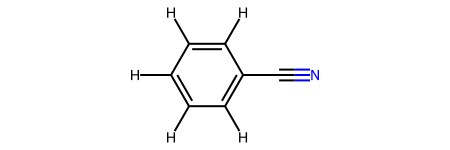

In [45]:
mol=Chem.MolFromSmiles("N#Cc1ccccc1")
mol=Chem.AddHs(mol)
mol

In [46]:
for item in polar_aprotic_solvents:
        print(f"item:{item}",solvent_qm_dataset.query("smile==@item").electrophilicity.values)

item:COCCOCCOC [0.03788139]
item:CCOC [0.00163135]
item:COC [0.00111784]
item:CN1CCN(C)C1=O [0.19692335]
item:N#Cc1ccccc1 [1.08033587]
item:CC1CN1C(=O)N(C)C [0.3776432]
item:CN1CCCCC1=O [0.34942814]
item:CCCC#N [0.35288123]
item:CS(C)=O [0.41354327]
item:O=P(Cl)(Cl)Cl [1.2603502]
item:COCCOCCOCCOC [0.02125638]
item:C[N+](=O)[O-] [1.37956831]
item:CC1=CC(=C(C#N)C#N)C=C(C=Cc2ccc(N(C)C)cc2)O1 [1.41125634]
item:COC(C)=O [0.59005537]
item:COCCOC [0.00533617]
item:Clc1ccccc1 [0.71636672]
item:CC(=O)N(C)C [0.3453757]
item:CN(C)P(=O)(N(C)C)N(C)C [0.05670556]
item:CCC#N [0.39720593]
item:CC(=O)N(C)C [0.3453757]
item:O=[N+]([O-])c1ccccc1 [1.71213015]
item:CCC(=O)CC [0.56424227]
item:CC(=O)OC(C)=O [1.06686898]
item:COC(=O)c1ccccc1C(=O)OC [1.15420478]
item:c1ccncc1 [0.70870364]
item:CCN(CC)C(C)=O [0.32522817]
item:O=S1(=O)CCCC1 [0.2725109]
item:CN1CCCN(C)C1=O [0.17773679]
item:CCOC(C)=O [0.52776144]
item:CC#N [0.46300735]
item:CN(C)C=O [0.38208073]
item:[2H]C(=O)N(C([2H])([2H])[2H])C([2H])([2H])[2

In [40]:
polar_aprotic_solvents = [
    'COCCOCCOC',     # 二甘醇二甲醚
    'CCOC',          # 乙基甲醚
    'COC',           # 甲基乙醚
    'CN1CCN(C)C1=O', # 哌嗪
    'N#Cc1ccccc1',   # 苯腈
    'CC1CN1C(=O)N(C)C', # 氮杂环丙烷酮
    'CN1CCCCC1=O',   # 哌啶酮
    'CCCC#N',        # 丁腈
    'CS(C)=O',       # 二甲基亚砜
    'O=P(Cl)(Cl)Cl', # 三氯氧磷
    'COCCOCCOCCOC',  # 三甘醇
    'C[N+](=O)[O-]', # 硝基甲烷
    'CC1=CC(=C(C#N)C#N)C=C(C=Cc2ccc(N(C)C)cc2)O1',  # 二氰基苯
    'COC(C)=O',      # 甲醚
    'COCCOC',        # 二乙基醚
    'Clc1ccccc1',    # 氯苯
    'CC(=O)N(C)C',   # 二甲基乙酰胺
    'CN(C)P(=O)(N(C)C)N(C)C',  # N,N,N',N'-四甲基磷酰胺
    'CCC#N',         # Acetonitrile
    'CC(=O)N(C)C',   # N,N-Dimethylacetamide
    'O=[N+]([O-])c1ccccc1',  # Nitrobenzene
    'CCC(=O)CC',     # Acetone
    'CC(=O)OC(C)=O', # Diethyl malonate
    'COC(=O)c1ccccc1C(=O)OC', # Dibenzyl malonate
    'c1ccncc1',
    'CCN(CC)C(C)=O',
    'O=S1(=O)CCCC1',
    'CN1CCCN(C)C1=O',
    'CCOC(C)=O',
    'CC#N',
    'CN(C)C=O',
    '[2H]C(=O)N(C([2H])([2H])[2H])C([2H])([2H])[2H]',
    '[2H]C([2H])([2H])S(=O)C([2H])([2H])[2H]',
    '[2H]C([2H])(Cl)Cl',
    'CN1CCOCC1',
    'CCCCn1cc[n+](C)c1',
    'CCCC[n+]1ccn(C)c1',
    '[2H]C([2H])([2H])N(C=O)C([2H])([2H])[2H]',
    '[2H]C1([2H])OC([2H])([2H])C([2H])([2H])C1([2H])[2H]',
    'CC(C)C#N',
    'BrCBr',
    'ClCCl',
    'CCOCCOCC',
    'ClCCCl',
    'CC(Cl)Cl',
    'CN1CCCC1=O',
    'CC[N+](=O)[O-]',
    'O=S(Cl)Cl',
    'F[B-](F)(F)F',
    'F[P-](F)(F)(F)(F)F',
    'CC(Cl)(Cl)Cl',
    'c1ccncc1', 
    'COC(=O)c1ccccc1C(=O)OC', 
    'CCCCOC(C)=O', 
    'CC(=O)CC(C)C', 
    'CC(C)=O',
    'CCC(C)=O',
    'Fc1ccccc1',
    'Clc1ccccc1Cl',
    'Cc1ccc(F)c(F)c1F',
    'C1CCOC1',
    'Cc1cc(C)nc(C)c1',
    'CN(C)c1ccccc1',
    'C1CCOOC1',
    'COCCOCCOCCOCCOC',
    'C1COCOC1',
    'CC(=O)OC(C)C',  # 乙酸异丙酯
]

In [47]:
cls_set=set(non_polar_solvents+polar_protic_solvents+polar_aprotic_solvents)
organsolvset=colset-set(special_solv_dict.keys())
print(cls_set-organsolvset)
print(organsolvset-cls_set)
print(set(polar_aprotic_solvents)&set(polar_protic_solvents))

set()
set()
set()


### Check

In [53]:
notfound=set()
# for item in set(non_polar_solvents+polar_protic_solvents+polar_aprotic_solvents):
for item in set(polar_protic_solvents+polar_aprotic_solvents):
# for item in set(non_polar_solvents):
    if item not in dataset_set:
        notfound.add(item)
        if solvent_qm_dataset.query('smile==@item')[['dipole']].values*2<1.0:
            # print(item,"QM")
            print("QM calc",item,solvent_qm_dataset.query('smile==@item')[['dipole']].values*2)
    else:
        # pass
        if solvent_dataset.query('smiles==@item')[['Dielectric constant']].values<8 and solvent_dataset.query('smiles==@item')[['Dipole moment (D)']].values<1.5:
            # print(item)
            print(item,solvent_dataset.query('smiles==@item')[['Dielectric constant','Dipole moment (D)']].values)

QM calc F[B-](F)(F)F [[0.07094062]]
QM calc CCCCn1cc[n+](C)c1 [[0.35281941]]
QM calc CCCC[n+]1ccn(C)c1 [[0.34254478]]


起初有争议的non polar 标准dipole>1.5, or dielectric const>8
- 'CCCCCCCCO'            Fluorobenzene
- 'Fc1ccccc1',           1,2-Dichlorobenzene
- 'Clc1ccccc1Cl',        1,2,3-trifluoro-4-methylbenzene
- 'Cc1ccc(F)c(F)c1F',      Tetrahydrofuran
- 'C1CCOC1',              1-Octanol
- 'Cc1cc(C)nc(C)c1',      2,4,6-Trimethylpyridine
- 'CN(C)c1ccccc1',      Dimethylaniline

有争议的polar 有exp data全放入到了non-polar中  dipole<1.5, and dielectric const<8
- CCNCC                                                         N-ethylethanamine
- CCOCC                                                         Ethoxyethane
- ClC(Cl)Cl                                                     Chloroform
- CC(C)NC(C)C                                                   Diisopropylamine
- COCOC                                                         Dimethoxymethane
- CCN(CC)CC                                                     TRIETHYLAMINE
- COC(C)(C)C                                                    Methyl tert-butyl ether (MTBE)
- COc1ccccc1                                                    Methoxybenzene
有争议的poloar，仅有qm data dipole<1.0全放入到non-polar中，B-硼酸除外 n+
- [2H]C(Cl)(Cl)Cl [[0.93251516]]
- COC1CCC1OC [[0.69118089]]
- CNCCNC [[0.09495489]]
- CN1CCNCC1 [[0.2288895]]
- CC(=NO)C(C)=NO [[0.6396219]]
- [2H]C1([2H])OC([2H])([2H])C([2H])([2H])OC1([2H])[2H] [[3.08031989e-06]]
- FC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F [[0.04960711]]
- FC(F)(Cl)Cl [[0.89342755]]

#### Substract matching

##### OH、NH

In [54]:
pattern_mol

In [55]:
polar_aprotic_solvents

['COCCOCCOC',
 'CCOC',
 'COC',
 'CN1CCN(C)C1=O',
 'N#Cc1ccccc1',
 'CC1CN1C(=O)N(C)C',
 'CN1CCCCC1=O',
 'CCCC#N',
 'CS(C)=O',
 'O=P(Cl)(Cl)Cl',
 'COCCOCCOCCOC',
 'C[N+](=O)[O-]',
 'CC1=CC(=C(C#N)C#N)C=C(C=Cc2ccc(N(C)C)cc2)O1',
 'COC(C)=O',
 'COCCOC',
 'Clc1ccccc1',
 'CC(=O)N(C)C',
 'CN(C)P(=O)(N(C)C)N(C)C',
 'CCC#N',
 'CC(=O)N(C)C',
 'O=[N+]([O-])c1ccccc1',
 'CCC(=O)CC',
 'CC(=O)OC(C)=O',
 'COC(=O)c1ccccc1C(=O)OC',
 'c1ccncc1',
 'CCN(CC)C(C)=O',
 'O=S1(=O)CCCC1',
 'CN1CCCN(C)C1=O',
 'CCOC(C)=O',
 'CC#N',
 'CN(C)C=O',
 '[2H]C(=O)N(C([2H])([2H])[2H])C([2H])([2H])[2H]',
 '[2H]C([2H])([2H])S(=O)C([2H])([2H])[2H]',
 '[2H]C([2H])(Cl)Cl',
 'CN1CCOCC1',
 'CCCCn1cc[n+](C)c1',
 'CCCC[n+]1ccn(C)c1',
 '[2H]C([2H])([2H])N(C=O)C([2H])([2H])[2H]',
 '[2H]C1([2H])OC([2H])([2H])C([2H])([2H])C1([2H])[2H]',
 'CC(C)C#N',
 'BrCBr',
 'ClCCl',
 'CCOCCOCC',
 'ClCCCl',
 'CC(Cl)Cl',
 'CN1CCCC1=O',
 'CC[N+](=O)[O-]',
 'O=S(Cl)Cl',
 'F[B-](F)(F)F',
 'F[P-](F)(F)(F)(F)F',
 'CC(Cl)(Cl)Cl',
 'c1ccncc1',
 'COC(=O)c1ccc

In [ ]:
 'COCCOCCOC',
 'CCOC',
 'COC',
 'CN1CCN(C)C1=O',
 'N#Cc1ccccc1',
 'CC1CN1C(=O)N(C)C',
 'CN1CCCCC1=O',
 'CCCC#N',
 'CS(C)=O',
 'O=P(Cl)(Cl)Cl',
 'COCCOCCOCCOC',
 'C[N+](=O)[O-]',
 'CC1=CC(=C(C#N)C#N)C=C(C=Cc2ccc(N(C)C)cc2)O1',
 'COC(C)=O',
 'COCCOC',
 'Clc1ccccc1',
 'CC(=O)N(C)C',
 'CN(C)P(=O)(N(C)C)N(C)C',
 'CCC#N',
 'CC(=O)N(C)C',
 'O=[N+]([O-])c1ccccc1',
 'CCC(=O)CC',
 'CC(=O)OC(C)=O',
 'COC(=O)c1ccccc1C(=O)OC',
 'c1ccncc1',
 'CCN(CC)C(C)=O',
 'O=S1(=O)CCCC1',
 'CN1CCCN(C)C1=O',
 'CCOC(C)=O',
 'CC#N',
 'CN(C)C=O',
 '[2H]C(=O)N(C([2H])([2H])[2H])C([2H])([2H])[2H]',
 '[2H]C([2H])([2H])S(=O)C([2H])([2H])[2H]',
 '[2H]C([2H])(Cl)Cl',
 'CN1CCOCC1',
 'CCCCn1cc[n+](C)c1',
 'CCCC[n+]1ccn(C)c1',
 '[2H]C([2H])([2H])N(C=O)C([2H])([2H])[2H]',
 '[2H]C1([2H])OC([2H])([2H])C([2H])([2H])C1([2H])[2H]',
 'CC(C)C#N',
 'BrCBr',
 'ClCCl',
 'CCOCCOCC',
 'ClCCCl',
 'CC(Cl)Cl',
 'CN1CCCC1=O',
 'CC[N+](=O)[O-]',
 'O=S(Cl)Cl',
 'F[B-](F)(F)F',
 'F[P-](F)(F)(F)(F)F',
 'CC(Cl)(Cl)Cl',
 'c1ccncc1',
 'COC(=O)c1ccccc1C(=O)OC',
 'CCCCOC(C)=O',
 'CC(=O)CC(C)C',
 'CC(C)=O',
 'CCC(C)=O',
 'Fc1ccccc1',
 'Clc1ccccc1Cl',
 'Cc1ccc(F)c(F)c1F',
 'C1CCOC1',
 'Cc1cc(C)nc(C)c1',
 'CN(C)c1ccccc1',
 'C1CCOOC1',
 'COCCOCCOCCOCCOC',
 'C1COCOC1',
 'CC(=O)OC(C)C'

In [58]:
pattern_mol = [
                # Chem.MolFromSmarts('['
                #                      '$([N&!H0&v3,N&!H0&+1&v4,n&H1&+0]),'
                #                      '$([$(n[n;H1]),$(nc[n;H1])]),'
                #                      '$([Nv3;$([N;H0]=C-[N;!H0])]),'
                #                      '$([O,S;H1;+0;!$(O-[C;v4]=[O;H0])]),'
                #                      '$([H][O][H])]'
                #                      )]
                Chem.MolFromSmarts('[$([N,O;H1,H2])]'),
                # Chem.MolFromSmarts('[N;H1,H2]'),
                # Chem.MolFromSmarts('[O;H1,H2]')
] 
def search_pattern(smiles):
    mol=Chem.MolFromSmiles(smiles)
    mol=Chem.AddHs(mol)
    match=False
    for patmol in pattern_mol:
        if len(mol.GetSubstructMatches(patmol))>0:
            match=True
    return match
for smi in polar_aprotic_solvents:
    if search_pattern(smi):
        print(f"SMILES: {smi}")

In [59]:
mol=Chem.MolFromSmiles('c1ccncc1')
mol=Chem.AddHs(mol)
# patmol=Chem.MolFromSmarts('[H][O][H]')
mol.GetSubstructMatches(patmol)

NameError: name 'patmol' is not defined

In [62]:
from rdkit import Chem

def contains_OH_or_NH(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    
    # 定义 OH 和 NH 的 SMARTS 模式
    OH_smarts = Chem.MolFromSmarts('[O;H1,H2]')  # 更广泛的OH基团匹配，包括水
    NH_smarts = Chem.MolFromSmarts('[N;H1,H2]')  # 更广泛的NH基团匹配
    
    # 检查是否存在 OH 或 NH
    contains_OH = mol.HasSubstructMatch(OH_smarts)
    contains_NH = mol.HasSubstructMatch(NH_smarts)
    contains_OD = mol.HasSubstructMatch(OD_smarts)   
    
    return contains_OH, contains_NH

# 示例：检查SMILES
for smi in polar_aprotic_solvents:
    has_OH, has_NH = contains_OH_or_NH(smi)    
    if has_OH or has_NH:
        print(f"SMILES: {smi}")
        # print(f"Contains OH: {has_OH}")
        # print(f"Contains NH: {has_NH}")

# for smi in polar_protic_solvents:
#     has_OH, has_NH = contains_OH_or_NH(smi)    
#     if not has_OH and not has_NH:
#         print(smi)
    # print(f"SMILES: {smi}")
    # print(f"Contains OH: {has_OH}")
    # print(f"Contains NH: {has_NH}")

True


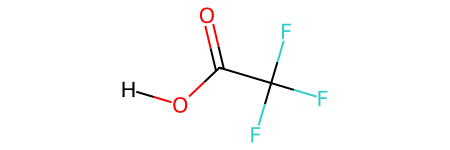

In [61]:
mol = Chem.MolFromSmiles('O=C(O)C(F)(F)F')
mol = Chem.AddHs(mol)
# 定义 OH 和 NH 的 SMARTS 模式
OH_smarts = Chem.MolFromSmarts('[O;H1,H2]')  # 匹配氧上有一个氢原子的OH
OD_smarts = Chem.MolFromSmarts('[O&2H1]')  # 匹配OD基团（氘）
contains_OH = mol.HasSubstructMatch(OH_smarts)
contains_OD = mol.HasSubstructMatch(OD_smarts)
print(contains_OH)
mol

- 元素：N、F、Br、Cl、P、S、O
- 官能团：
    - 胺类溶剂（-NH₂, -N(CH₃)₂）、酰胺N-C=O
    - 醚类溶剂（-O-）、酮类溶剂（-C=O）、酯类溶剂（-COO-）、醇类溶剂（-OH）、
- 环状结构
- 特征：离子、硫酸O=S(=O)(O)O，盐酸Cl、硼酸

官能团
- N
    - C=N双键
    - C#N三键
    - NO2硝基
    - 酰胺N-C=O
    - 胺基（-NH₂, -N(CH₃)₂）
    - [N+]
- F
    - 是否含F
- Br、Cl
    - 是否含Br Cl
- P
    - 一共三种，不知道怎么使用，是否含P
- S
    - 是否含硫 一共不多
    - 亚砜类  S=O 
- O
    - 醚类溶剂（-O-）、酮类溶剂（-C=O）、酯类溶剂（-COO-）、醇类溶剂（-OH）、羧基（-COOH）、醛基（-CHO）
- 苯基
- 环状
- 离子
    - N+、O-、B-、P-

In [63]:
# colset
for item in colset:
    if "N+" in item:
        print(item)

CC[N+](=O)[O-]
C[N+](=O)[O-]
O=[N+]([O-])c1ccccc1


In [64]:
"CC[N+](=O)[O-]" in polar_aprotic_solvents

True

#### 检查实际的datasample

In [65]:
notfound=set()

smiles='CO.CN1CCNCC1.CC1=CC(=C(C#N)C#N)C=C(C=Cc2ccc(N(C)C)cc2)O1.ClCCl'
smileslist=smiles.split('.')
for item in smileslist:
    if item not in dataset_set:
        notfound.add(item)
    else:
        print(item,solvent_dataset.query('smiles==@item')[['Dielectric constant','Dipole moment (D)']].values)    

ClCCl [[8.93 1.14]]


### From Dataset

#### Import exp dataset

In [50]:
def canonical(smi):
    return Chem.MolToSmiles(Chem.MolFromSmiles(smi), isomericSmiles=True, canonical=True)
savepath='../data/solvents/'
solvent_dataset = pd.read_csv('../data/solvents/'+'solvent_withsmiles.csv')
solvent_dataset = solvent_dataset.dropna(subset=['smiles'])
solvent_dataset['smiles'] = solvent_dataset['smiles'].apply(canonical)

In [51]:
savepath='../data/solvents/'
solvent_dataset2 = pd.read_csv('../data/solvents/'+'MNSol_alldata_withsmiles.csv')
solvent_dataset2['smiles'] = solvent_dataset['smiles'].apply(canonical)

In [52]:
dataset_set = set(solvent_dataset.smiles)
dataset_set2 = set(solvent_dataset2.smiles)

#### Import QM dataset

In [41]:
def canonical(smi):
    return Chem.MolToSmiles(Chem.MolFromSmiles(smi), isomericSmiles=True, canonical=True)
savepath='../data/solvents/'
solvent_qm_dataset = pd.read_csv('../data/qm_desc-morfeus/'+'psikit_Solvent.csv.gz')

In [42]:
def canonical(smi):
    return Chem.MolToSmiles(Chem.MolFromSmiles(smi), isomericSmiles=True, canonical=True)
savepath='../data/solvents/'
solvent_qm_dataset2 = pd.read_csv('../data/qm_desc/'+'psikit_Solvent.csv.gz')

In [66]:
notfound=set()
x=[]
y=[]
for item in set(non_polar_solvents+polar_protic_solvents+polar_aprotic_solvents):
# for item in set(non_polar_solvents):
    if item not in dataset_set:
        item=canonical(item)
        # print(item,solvent_qm_dataset.query('smile==@item')[['dipole']].values)
    else:
        # print(item,solvent_qm_dataset.query('smile==@item')[['dipole']].values*2)
        # print(item,solvent_qm_dataset2.query('smi==@item')[['dipole_all']].values*2)
        # print(item,solvent_dataset.query('smiles==@item')[['Dipole moment (D)']].values)
        x.append(solvent_qm_dataset.query('smile==@item')[['dipole']].values*2)
        y.append(solvent_dataset.query('smiles==@item')[['Dipole moment (D)']])

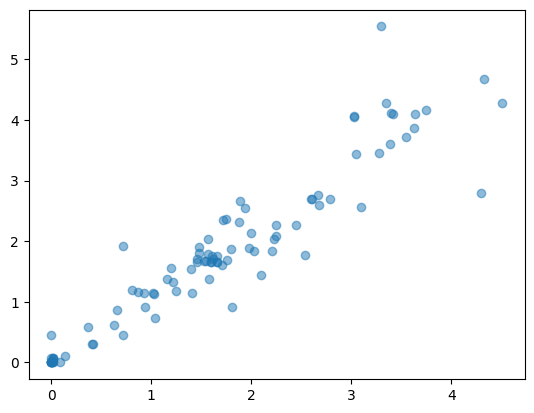

In [67]:
import matplotlib.pyplot as plt
import numpy as np
import logging

logging.getLogger('matplotlib.font_manager').disabled = True

plt.scatter(x, y,  alpha=0.5)
plt.show()

#### Save Literature

save Dataset 1

In [4]:

solvent_df = pd.read_csv('../data/solvents/'+'solvent.csv')
# solvent_df.columns

In [5]:
solvent_df=solvent_df.drop(['Solvent no.', 'Stenutz name'],axis=1)

In [6]:
solvent_df

,COSMO name,CAS number,Formula,MW (g/mol),Density (g/mL),Molar volume (mL/mol),Refractive index,Mol. refr. pow. (mL/mol),Dielectric constant,Dipole moment (D),Melting point (°C),Boiling point (°C),Viscosity (cP),lnP (partition coeff.),Vapour pressure (mbar),Henry's constant,lngamma,HBD,neutral,HBA
0,(trichloromethyl)-benzene,98-07-7,C7H5Cl3,195,1.173,166.6,1.557,53.67,6.900,2.14,-4,220,1.85,3.68,0.20,2015.87,1.23,0.2054,18.7984,0.0000
1,"1,5-cyclooctadiene",111-78-4,C8H12,108,0.880,122.9,1.493,35.73,2.380,0.17,-69,148,1.00,2.98,8.87,1884.53,1.44,0.0000,15.2165,0.4711
2,"trans,trans-2,4-hexadiene",5194-51-4,C6H10,82,0.727,112.9,1.456,30.70,2.220,0.36,-79,79,0.37,3.05,8.87,2089.16,1.47,0.0000,14.9023,0.0451
3,(dichloromethyl)-benzene,98-87-3,C7H6Cl2,161,1.250,128.8,1.550,41.04,6.900,2.05,-16,205,1.99,2.94,225.18,2235.31,-0.05,0.8684,16.7703,0.0000
4,1-trans-3-pentadiene,2004-70-8,C5H8,68,0.683,99.7,1.430,25.77,2.320,0.68,-87,42,0.30,2.47,702.08,2326.13,1.16,0.0000,12.8734,0.0397
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
453,1-hexanol,111-27-3,C6H14O,102,0.814,126.0,1.418,31.63,13.300,1.65,-47,158,5.12,2.03,1.22,2001.85,0.40,0.7269,14.9099,1.1737
454,n-butylacetate,123-86-4,C6H12O2,116,0.880,132.0,1.394,31.60,5.010,1.84,-74,126,0.69,0.69,5.38,1964.05,0.20,0.0353,15.5485,1.7771
455,triethyl orthoformate,122-51-0,C7H16O3,148,0.893,166.0,1.390,39.34,4.779,1.67,-61,143,1.08,1.79,0.56,1758.45,0.22,0.0000,18.6336,2.1443
456,"n,n-dimethylacetamide",127-19-5,C4H9NO,87,0.942,92.5,1.438,24.31,37.780,3.72,-20,165,0.63,-0.50,10.11,2548.20,-0.95,0.0151,11.4326,1.8365


In [8]:
cirpy.resolve('108-95-2', 'smiles')

'Oc1ccccc1'

In [7]:
import cirpy
def casid_smiles(name):
    return cirpy.resolve(name, 'smiles')
solvent_df['smiles'] = solvent_df['CAS number'].apply(casid_smiles)

In [9]:
savepath='../data/solvents/'
solvent_df.to_csv(savepath+f'solvent_withsmiles.csv', index=False)

save Dataset2

In [74]:
solvent_df = pd.read_csv('../data/solvents/'+'MNSol_alldata.csv')
# solvent_df.columns

In [83]:
interested_set=['Solvent','alpha', 'beta', 'beta**2', 'eps', 'gamma', 'n', 'phi**2', 'psi**2']
solvent_df_uniquesol = solvent_df.drop_duplicates(subset='Solvent')
solvent_df_uniquesol=solvent_df_uniquesol[interested_set]
solvent_df_uniquesol['smiles'] = solvent_df_uniquesol['Solvent'].apply(casid_smiles)
df_cleaned = solvent_df_uniquesol.dropna(subset=['smiles'])

In [84]:
savepath='../data/solvents/'
df_cleaned.to_csv(savepath+f'MNSol_alldata_withsmiles.csv', index=False)

In [86]:
import deepchem as dc
from rdkit.Chem import Descriptors
from skfp.fingerprints import AtomPairFingerprint, ECFPFingerprint, MACCSFingerprint, GhoseCrippenFingerprint, E3FPFingerprint,MordredFingerprint

def get_fpandft(train_df):
    train_rct1_smi = train_df['Reactant1'].to_list()
    train_rct2_smi = train_df['Reactant2'].to_list()
    train_add_smi = train_df['Additive'].to_list()
    train_sol_smi = train_df['Solvent'].to_list()
    train_prod_smi = train_df['Product'].to_list()
    for item in atom_id:
        train_rct1_fp=fp.transform(train_rct1_smi)
        train_rct2_fp=fp.transform(train_rct2_smi)
        train_add_fp=fp.transform(train_add_smi)
        train_sol_fp=fp.transform(train_sol_smi)
        train_prod_fp=fp.transform(train_prod_smi)

    train_x = np.concatenate([train_rct1_fp,train_rct2_fp,train_add_fp,train_sol_fp,train_prod_fp],axis=1)
    return train_x

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (/home/hcsgxl/miniconda3/envs/chemprop/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-geometric dependency, missing a dependency. cannot import name 'DMPNN' from 'deepchem.models.torch_models' (/home/hcsgxl/miniconda3/envs/chemprop/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


## 训练

In [89]:
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.model_selection import train_test_split, StratifiedKFold,KFold
import gc
import os
from pathlib import Path

n_rxn = 9
n_splits = 5

ckpt_base_path='ckpt-lgbm-fpandft-5folds'
Path(ckpt_base_path).mkdir(exist_ok=True, parents=True)

kfold = KFold(n_splits=n_splits, random_state=42, shuffle=True)

for j in range(1,n_rxn):
    models = []
    scores = []
    train_df=train_df_dict[j]    
    train_x,train_y=get_fpandft(train_df)    
    i=1
    model_save_path=os.path.join(ckpt_base_path,f"rxn_{j}")
    Path(model_save_path).mkdir(exist_ok=True, parents=True)
    
    for train_index, test_index in kfold.split(train_x, train_y):       
        print('fold',i)
        X_train_fold, X_test_fold = train_x[train_index], train_x[test_index]   
        y_train_fold, y_test_fold= train_y[train_index], train_y[test_index]
    
        lgb_params = {
        "objective": "mse",
        "n_estimators": 5000, #Tuning
        "num_leaves": 256,
        "subsample": 0.6,
        "colsample_bytree": 0.6,
        "learning_rate": 0.00871,
        "n_jobs": 4,
        "verbosity": -1,
        "importance_type": "gain",
        }
        
        model = lgb.LGBMRegressor(**lgb_params)
    
        predictor = model.fit(X_train_fold,
                                      y_train_fold,
                                      eval_names=['train', 'valid'],
                                      eval_set=[(X_train_fold, y_train_fold), (X_test_fold, y_test_fold)],
                                      callbacks=[
                                        lgb.callback.early_stopping(stopping_rounds=100),
                                        lgb.callback.log_evaluation(period=100)],
                             )
    
        models.append(predictor)
        predictions_fold = predictor.predict(X_test_fold)
    
        # Save the model to a file
        model_filename = os.path.join(model_save_path, f'lgbm_fold{i}.txt')
        predictor.booster_.save_model(model_filename)
        print(f"Model for fold {i+1} saved to {model_filename}")
    
        # Evaluate model performance on the validation set
        fold_predictions = predictor.predict(X_test_fold)
        fold_score = mean_squared_error(fold_predictions, y_test_fold)
        scores.append(fold_score)
        print(f"Fold {i} MSE: {fold_score}")
        i+=1
    
    average_best_iteration = int(np.mean([model.best_iteration_ for model in models]))
    # Update the lgb_params with the average best iteration
    final_model_params = lgb_params.copy()
    final_model_params['n_estimators'] = average_best_iteration
    
    print(f"Training final model with average best iteration: {average_best_iteration}")
    
    # Train the final model on the entire dataset
    final_model = lgb.LGBMRegressor(**final_model_params)
    final_model.fit(
        train_x,train_y,callbacks=[
            lgb.callback.log_evaluation(period=100),
        ],
    )
    
    # Append the final model to the list of models
    models.append(final_model)
    
    # Save the final model to a file
    final_model_filename = os.path.join(model_save_path, 'lgbm_fold_final.txt')
    final_model.booster_.save_model(final_model_filename)
    print(f"Final model saved to {final_model_filename}")
    
    # Now 'models' holds the trained models for each fold and 'scores' holds the validation scores
    print(f"Average MAE across all folds: {np.mean(scores)}")

NameError: name 'atom_id' is not defined